In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import kagglehub

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

data_dir = os.path.join(path, "plantvillage dataset", "color")

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Classes:", len(dataset.classes))

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Classes: 38


In [3]:
target_class = "Potato___healthy"
class_idx = dataset.class_to_idx[target_class]

indices = [i for i, label in enumerate(dataset.targets) if label == class_idx]

potato_dataset = Subset(dataset, indices)

print("Potato samples:", len(potato_dataset))

Potato samples: 152


In [4]:
batch_size = 32

dataloader = DataLoader(potato_dataset, batch_size=batch_size, shuffle=True)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),  # 4x4
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),  # 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),  # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),   # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),     # 64x64 ✅
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 64 → 32
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1), # 32 → 16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1), # 16 → 8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1), # 8 → 4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, 1, 0),   # 4 → 1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

In [8]:
latent_dim = 100

generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

generator.apply(weights_init)
discriminator.apply(weights_init)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1))
    (12): Sigmoid()
  )
)

In [9]:
criterion = nn.BCELoss()

optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_g = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [12]:
epochs = 20

for epoch in range(epochs):
    for real_images, _ in dataloader:
        real_images = real_images.to(device)

        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # Generate fake
        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake_images = generator(noise)

        # Train D
        d_real = discriminator(real_images)
        d_fake = discriminator(fake_images.detach())

        loss_d = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        optimizer_d.zero_grad()
        loss_d.backward()
        optimizer_d.step()

        # Train G
        output = discriminator(fake_images)
        loss_g = criterion(output, real_labels)

        optimizer_g.zero_grad()
        loss_g.backward()
        optimizer_g.step()

    print(f"Epoch {epoch+1} | D: {loss_d.item():.4f} | G: {loss_g.item():.4f}")

Epoch 1 | D: 0.4726 | G: 6.3477
Epoch 2 | D: 2.8176 | G: 16.5168
Epoch 3 | D: 0.9458 | G: 12.8839
Epoch 4 | D: 1.7761 | G: 11.4790
Epoch 5 | D: 0.3398 | G: 6.8789
Epoch 6 | D: 0.4293 | G: 7.8882
Epoch 7 | D: 0.3877 | G: 6.1538
Epoch 8 | D: 0.4212 | G: 4.5923
Epoch 9 | D: 0.5345 | G: 7.2631
Epoch 10 | D: 0.8683 | G: 9.3610
Epoch 11 | D: 0.1973 | G: 4.9553
Epoch 12 | D: 0.2922 | G: 4.6363
Epoch 13 | D: 0.5473 | G: 6.0181
Epoch 14 | D: 0.2189 | G: 5.3219
Epoch 15 | D: 0.7532 | G: 2.0004
Epoch 16 | D: 0.4745 | G: 4.3041
Epoch 17 | D: 0.4102 | G: 4.6613
Epoch 18 | D: 0.8523 | G: 4.8923
Epoch 19 | D: 0.8768 | G: 6.2709
Epoch 20 | D: 0.5824 | G: 2.7223


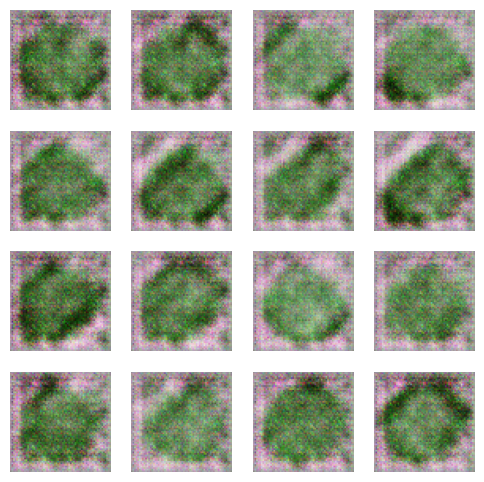

In [13]:
noise = torch.randn(16, latent_dim, 1, 1, device=device)
fake_images = generator(noise).detach().cpu()

fake_images = (fake_images + 1) / 2  # denormalize

fig, axes = plt.subplots(4, 4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    img = fake_images[i].permute(1, 2, 0)
    ax.imshow(img)
    ax.axis("off")

plt.show()

In [44]:
num_samples = 200

noise = torch.randn(num_samples, latent_dim, 1, 1, device=device)
fake_images = generator(noise).detach().cpu()

# ❗ ensure 64×64 (just in case)
import torch.nn.functional as F
fake_images = F.interpolate(fake_images, size=(64, 64))

fake_images = (fake_images + 1) / 2
from torch.utils.data import TensorDataset
fake_labels = torch.full((num_samples,), class_idx)
gan_dataset = TensorDataset(fake_images, fake_labels)

In [15]:
from torch.utils.data import ConcatDataset, DataLoader, random_split, Subset
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report

In [64]:
transform_cnn = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
class ToTensorDataset(torch.utils.data.Dataset):
  def __init__(self, dataset):
      self.dataset = dataset

  def __len__(self):
      return len(self.dataset)

  def __getitem__(self, idx):
      img, label = self.dataset[idx]
      return img, torch.tensor(label)
dataset_raw = datasets.ImageFolder(data_dir, transform=transform_cnn)
dataset_cnn = ToTensorDataset(dataset_raw)

In [65]:
train_size = int(0.7 * len(dataset_cnn))
val_size = int(0.15 * len(dataset_cnn))
test_size = len(dataset_cnn) - train_size - val_size

generator_seed = torch.Generator().manual_seed(42)

train_data, val_data, test_data = random_split(
    dataset_cnn,
    [train_size, val_size, test_size],
    generator=generator_seed
)

In [66]:
target_class = "Potato___healthy"
class_idx = dataset_raw.class_to_idx[target_class]

In [67]:
gan_subset = Subset(gan_dataset, list(range(min(100, len(gan_dataset)))))

In [68]:
augment_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ToTensor()
])
class ToTensorDataset(torch.utils.data.Dataset):
  def __init__(self, dataset):
      self.dataset = dataset

  def __len__(self):
      return len(self.dataset)

  def __getitem__(self, idx):
      img, label = self.dataset[idx]
      return img, torch.tensor(label)

aug_dataset = datasets.ImageFolder(data_dir, transform=augment_transform)
aug_dataset = ToTensorDataset(aug_dataset)

In [69]:
train_indices = train_data.indices

potato_indices = [
    i for i in train_indices
    if dataset_raw.targets[i] == class_idx
]
aug_subset = Subset(aug_dataset, list(range(min(150, len(aug_dataset)))))

print("Augmented potato samples:", len(aug_subset))

Augmented potato samples: 150


In [70]:
balanced_train_data = ConcatDataset([
    train_data,
    aug_subset,
    gan_subset
])

print("Final training size:", len(balanced_train_data))

Final training size: 38263


In [71]:
batch_size = 32

train_loader = DataLoader(balanced_train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

In [73]:

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(dataset_raw.classes))

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [74]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [75]:
print(train_data[0][0].shape)
print(aug_subset[0][0].shape)
print(gan_subset[0][0].shape)

torch.Size([3, 64, 64])
torch.Size([3, 64, 64])
torch.Size([3, 64, 64])


In [76]:
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.5388
Epoch 2, Loss: 0.2381
Epoch 3, Loss: 0.1766


In [77]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=dataset_raw.classes))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.91      0.44      0.59        91
                                 Apple___Black_rot       0.90      0.95      0.93        87
                          Apple___Cedar_apple_rust       0.93      0.38      0.54        37
                                   Apple___healthy       0.92      0.89      0.90       270
                               Blueberry___healthy       0.99      0.85      0.91       198
          Cherry_(including_sour)___Powdery_mildew       0.76      0.98      0.86       176
                 Cherry_(including_sour)___healthy       0.99      0.91      0.95       125
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.38      0.53        71
                       Corn_(maize)___Common_rust_       1.00      0.96      0.98       168
               Corn_(maize)___Northern_Leaf_Blight       0.77      0.95      0.

In [78]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=dataset_raw.classes,
    output_dict=True
)

print("Potato___healthy metrics:")
print(report["Potato___healthy"])

Potato___healthy metrics:
{'precision': 1.0, 'recall': 0.5, 'f1-score': 0.6666666666666666, 'support': 22.0}


In [79]:
before_recall = 0.14   # your baseline
after_recall = report["Potato___healthy"]["recall"]

print(f"Before GAN Recall: {before_recall}")
print(f"After GAN + Aug Recall: {after_recall}")
print(f"Improvement: {after_recall - before_recall}")

Before GAN Recall: 0.14
After GAN + Aug Recall: 0.5
Improvement: 0.36
